(streaming_dataset)=

# Out-of-core minibatch variational inference with DataLoader and Trainer

:::{post} June 2026
:tags: variational inference, minibatch, out-of-core
:category: intermediate, how-to
:author: Yicheng (Ethan) Yang
:::

`pm.Minibatch` random-indexes an array that must be fully resident in RAM, so
minibatch variational inference {cite:p}`hoffman2013stochastic,kucukelbir2015automatic`
only works on data that already fits in memory.
This notebook uses the streaming API in `pymc.variational.streaming`, which follows
the same structure as PyTorch's `torch.utils.data`:

* a {class}`~pymc.variational.streaming.DataLoader` batches (and optionally
  shuffles) an out-of-core source into fixed-size minibatches without loading
  the whole dataset into memory. Here the source is a directory of Parquet shards
  read by {func}`~pymc.variational.streaming.parquet_source`.
* the model observes a `pm.Data` placeholder of one batch, not the whole array.
* a {class}`~pymc.variational.streaming.Trainer` drives ADVI, writing each
  minibatch into that placeholder with `set_data` every step. There are no
  callbacks to write.

The unbiased-gradient rescaling works exactly as in `pm.Minibatch`. The `DataLoader`
is sized, so `total_size=len(loader)` passes the dataset size `N` to the observed
distribution, and PyMC scales the minibatch log-likelihood by `N / batch_size`.
Batches are exact-size, so each pass drops the rows that do not fill a final batch;
with `shuffle=True` that remainder is re-drawn every epoch instead of being a fixed
tail. The one extra requirement is shuffling itself. A streaming source is only as
well mixed as the order it yields rows in, so pass `DataLoader(shuffle=True)` to
shuffle through a bounded buffer.

`N` is small here so the notebook runs in seconds. The streaming code is the same at
any size, and the last section shows what changes at scale.

:::{include} ../extra_installs.md
:::

In [1]:
import glob
import tempfile

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pymc as pm

from pymc.variational.streaming import DataLoader, Trainer, parquet_source

RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## Put a dataset on disk and forget the array

We build a logistic-regression dataset, write it to Parquet shards, and delete the
in-memory table. From here the streaming path reads only the disk copy. We keep `X`
and `y` around only to build the in-RAM `pm.Minibatch` baseline later; the streaming
fit never reads them.

In [2]:
N = 30_000
b_true = np.array([0.4, -1.2, 0.8, -0.5])  # intercept + 3 slopes

X = rng.normal(size=(N, 3))
p = 1 / (1 + np.exp(-(b_true[0] + X @ b_true[1:])))
y = (rng.random(N) < p).astype("float64")
table = np.column_stack([X, y]).astype("float64")

shard_dir = tempfile.mkdtemp(prefix="streaming_demo_")
for i, s in enumerate(range(0, N, 5_000)):
    block = table[s : s + 5_000]
    pq.write_table(
        pa.table({f"c{j}": block[:, j] for j in range(4)}),
        f"{shard_dir}/part_{i:03d}.parquet",
    )
del table
print(len(glob.glob(f"{shard_dir}/*.parquet")), "shards written")

6 shards written


## Stream minibatches off disk and fit with ADVI

`parquet_source` is an out-of-core {class}`~pymc.variational.streaming.IterableDataset`.
It reads one shard at a time and gets `n_rows` from the Parquet metadata without
scanning the data, so `total_size="auto"` resolves `N` for free. The `DataLoader`
batches and shuffles it into fixed-size minibatches. The model reads a
`pm.Data("batch", ...)` placeholder holding a single batch, and the `Trainer`
writes each minibatch into it with `set_data`. There are no callbacks to wire up:
`total_size=len(loader)` triggers the `N / batch_size` rescaling and `Trainer.fit`
runs the loop.

In [3]:
batch_size = 1024
loader = DataLoader(
    parquet_source(shard_dir),
    batch_size=batch_size,
    sample_shape=(4,),  # 3 features + 1 observed column
    shuffle=True,  # the shards were written in order
    buffer_size=15_000,
    seed=0,
    total_size="auto",  # N from the Parquet metadata
)

with pm.Model() as model:
    b = pm.Normal("b", 0.0, 3.0, shape=4)
    batch = pm.Data("batch", np.zeros((batch_size, 4)))  # placeholder for one minibatch
    logit = b[0] + b[1] * batch[:, 0] + b[2] * batch[:, 1] + b[3] * batch[:, 2]
    pm.Bernoulli("y", logit_p=logit, observed=batch[:, 3], total_size=len(loader))

    approx = Trainer(
        method="advi",
        dataloader=loader,
        data_name="batch",
        obj_optimizer=pm.adam(learning_rate=0.008),
    ).fit(30_000, random_seed=RANDOM_SEED)
    idata_stream = approx.sample(1000, random_seed=RANDOM_SEED)

Finished [100%]: Average Loss = 531.47


The negative-ELBO trace shows the fit converging on minibatches read off disk:

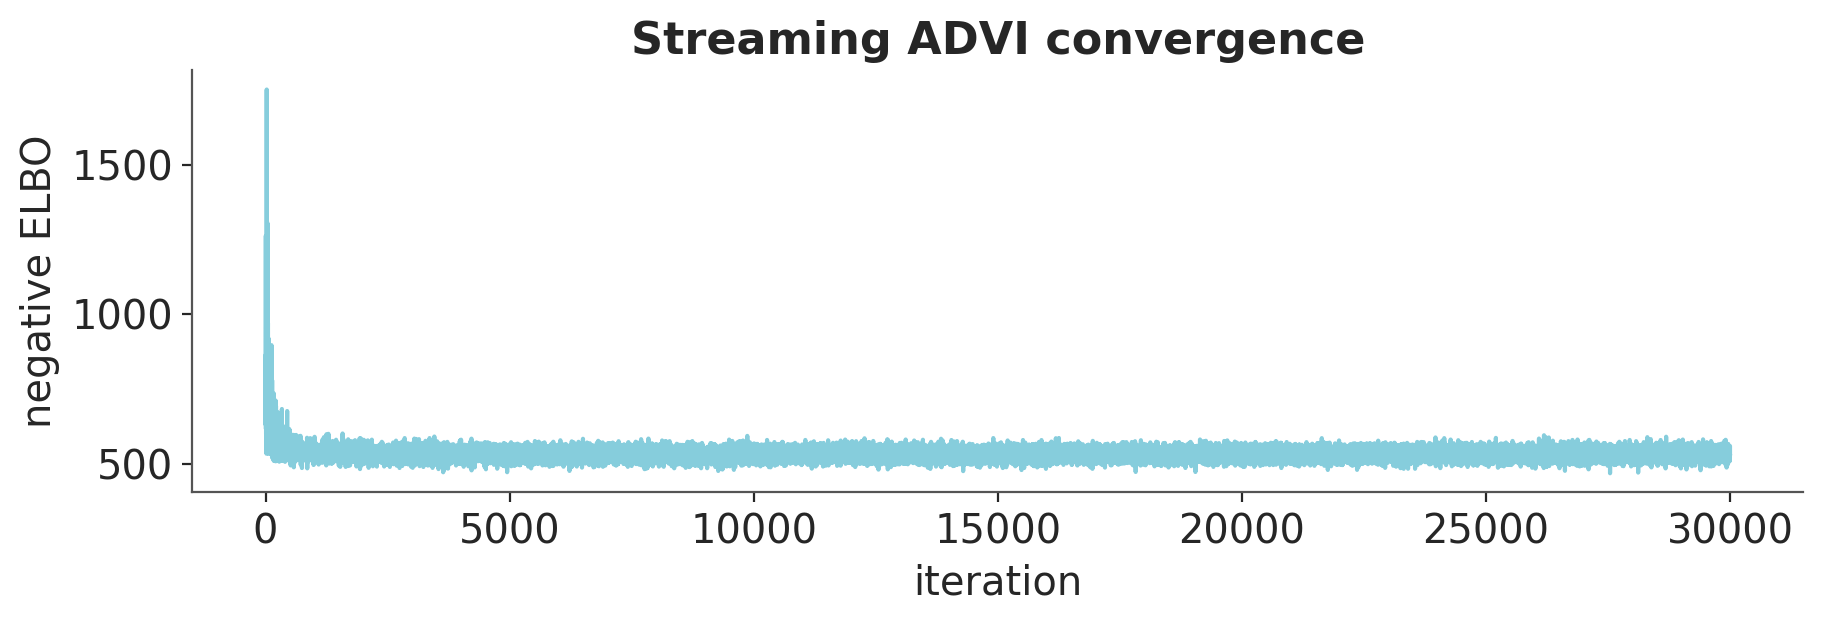

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(approx.hist, alpha=0.6)
ax.set(xlabel="iteration", ylabel="negative ELBO", title="Streaming ADVI convergence");

## The same posterior as in-RAM `pm.Minibatch`

For comparison, here is the usual fit that keeps the whole dataset in memory.
Streaming changes where the data lives, not the inference, so the two posteriors
should agree, and here they land on top of each other. Both show ADVI's usual mild
bias relative to the dashed ground truth, but they agree with each other.

In [5]:
with pm.Model():
    b = pm.Normal("b", 0.0, 3.0, shape=4)
    xb, zb, sb, yb = pm.Minibatch(
        X[:, 0].copy(), X[:, 1].copy(), X[:, 2].copy(), y, batch_size=batch_size
    )
    pm.Bernoulli("y", logit_p=b[0] + b[1] * xb + b[2] * zb + b[3] * sb, observed=yb, total_size=N)
    approx_inram = pm.fit(
        30_000,
        method="advi",
        obj_optimizer=pm.adam(learning_rate=0.008),
        progressbar=False,
        random_seed=RANDOM_SEED,
    )
    idata_inram = approx_inram.sample(1000, random_seed=RANDOM_SEED)

Finished [100%]: Average Loss = 531.25


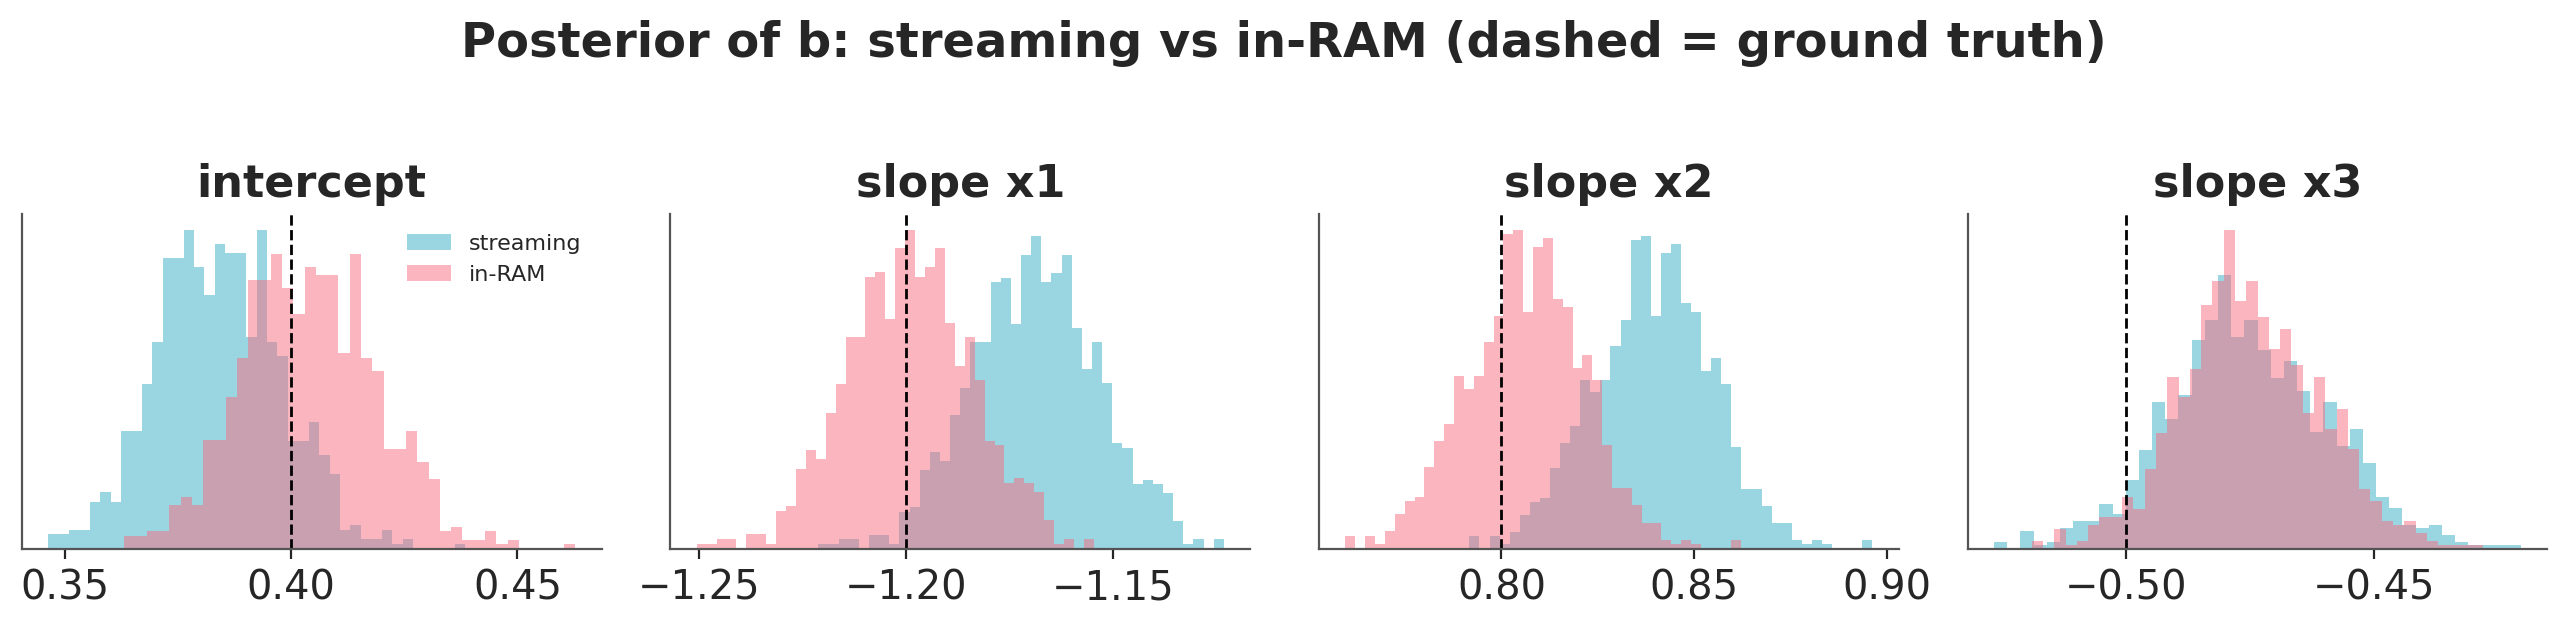

In [6]:
bs_stream = idata_stream.posterior["b"].values.reshape(-1, 4)
bs_inram = idata_inram.posterior["b"].values.reshape(-1, 4)
names = ["intercept", "slope x1", "slope x2", "slope x3"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3), layout="tight")
for k, ax in enumerate(axes):
    ax.hist(bs_stream[:, k], bins=40, density=True, alpha=0.5, label="streaming")
    ax.hist(bs_inram[:, k], bins=40, density=True, alpha=0.5, label="in-RAM")
    ax.axvline(b_true[k], color="k", ls="--", lw=1)
    ax.set(title=names[k], yticks=[])
axes[0].legend(fontsize=8)
fig.suptitle("Posterior of b: streaming vs in-RAM (dashed = ground truth)", y=1.04);

## Memory usage

Both paths feed the same `batch_size` to ADVI, but `pm.Minibatch` keeps all `N`
rows resident, so its array grows linearly in `N`, while the streaming `DataLoader`
holds one batch plus its bounded shuffle buffer and the current source chunk. The
dense `float64` design matrix dominates the cost. The lines below are array lower
bounds (`N * ncols * 8` bytes resident versus that constant), not measurements:

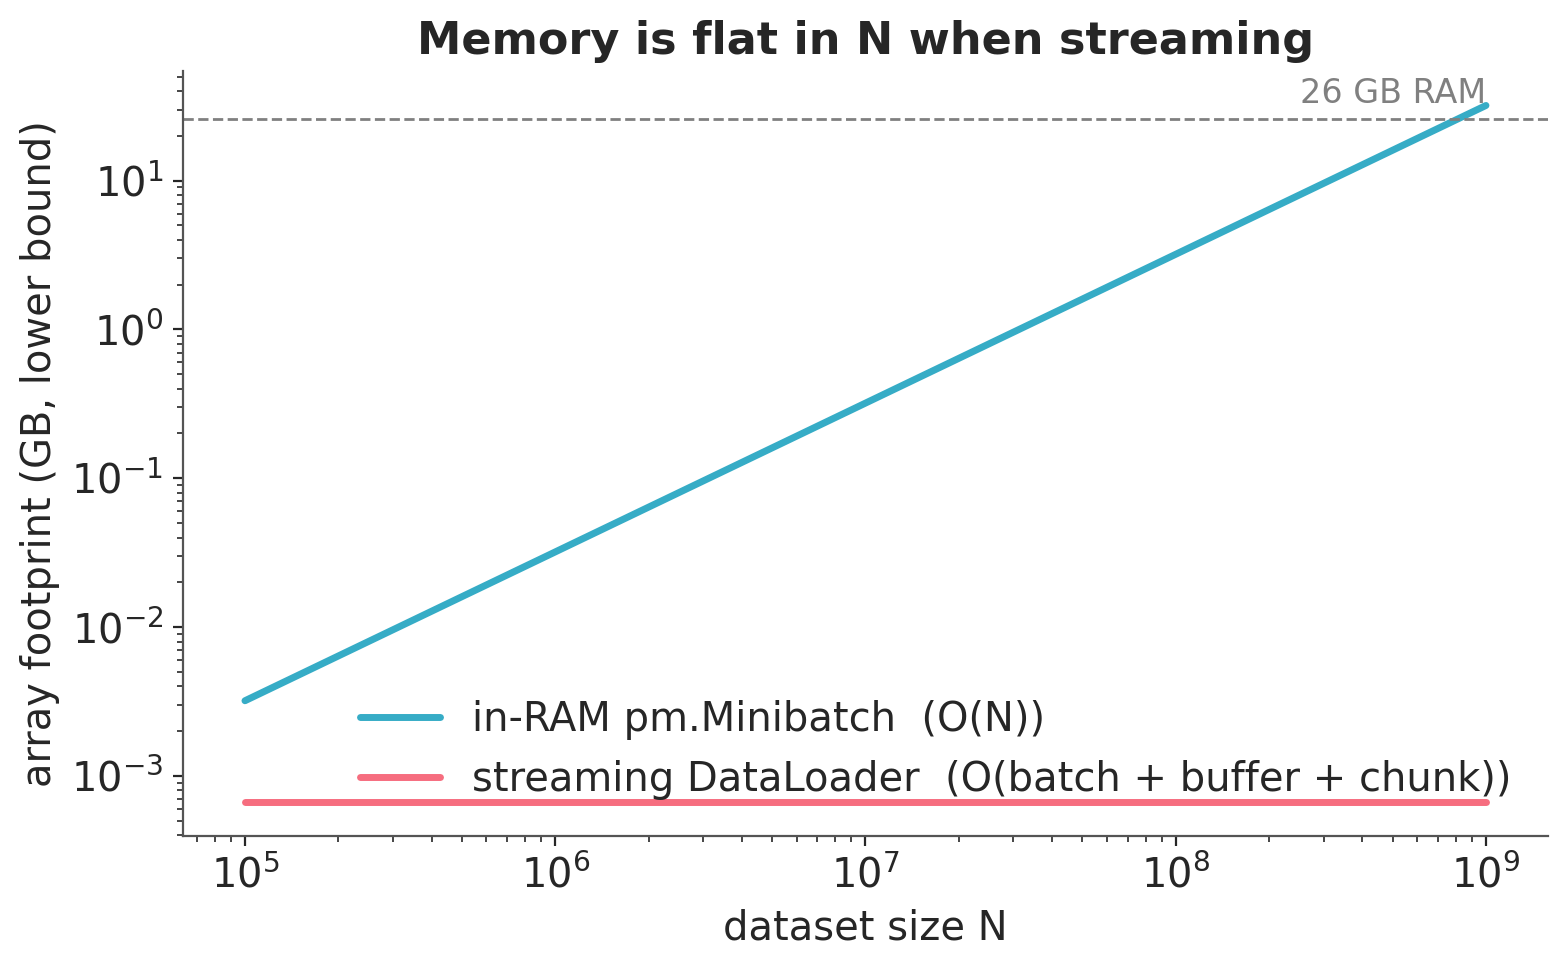

In [7]:
ncols = 4  # 3 features + observed
n_grid = np.logspace(5, 9, 50)
inram_gb = n_grid * ncols * 8 / 1e9  # whole dataset resident (array lower bound)
stream_rows = batch_size + 15_000 + 5_000  # one batch + shuffle buffer + one shard
stream_gb = np.full_like(n_grid, stream_rows * ncols * 8 / 1e9)

fig, ax = plt.subplots(figsize=(8, 5), layout="tight")
ax.loglog(n_grid, inram_gb, lw=2.5, label="in-RAM pm.Minibatch  (O(N))")
ax.loglog(n_grid, stream_gb, lw=2.5, label="streaming DataLoader  (O(batch + buffer + chunk))")
ax.axhline(26, color="0.5", ls="--", lw=1)
ax.text(n_grid[-1], 30, "26 GB RAM", color="0.5", ha="right", va="bottom")
ax.set_xlabel("dataset size N")
ax.set_ylabel("array footprint (GB, lower bound)")
ax.set_title("Memory is flat in N when streaming")
ax.legend(loc="lower right", framealpha=0.95);

Those lines are only the bare arrays. Actual peak RSS is higher, because of the
framework and PyTensor's resident copy, and it hits the RAM ceiling sooner. As a
real-data check, outside this notebook, we ran the same logistic model (13 numeric
features plus the click label) on the
[Criteo 1TB Click Logs](https://huggingface.co/datasets/criteo/CriteoClickLogs), a
standard, publicly available out-of-core learning benchmark. Peak memory for the
streaming `DataLoader` stayed flat at about 0.7 GB across a sweep from 1M to 150M
rows, while the in-RAM `pm.Minibatch` baseline rose linearly to 15.7 GB at 150M
rows, which extrapolates to out-of-memory around 250M rows on the same 26 GB
machine. The streaming and in-RAM posteriors agreed coefficient for coefficient;
the largest gap was about 0.1, on the intercept.

## When to use it

* Use `pm.Minibatch` when the data fits in RAM: it is simpler and its random
  index gives perfectly i.i.d. minibatches for free.
* Use the streaming `DataLoader` and `Trainer` when it does not: it keeps memory
  flat in `N` by streaming from disk, with no callbacks to wire up. The one thing to
  watch is shuffling. Pass `shuffle=True`, or pre-shuffle on disk and interleave
  shards for strongly ordered data, since a bounded buffer over strongly ordered
  data only block-shuffles it and can bias the posterior.

## Authors

* Authored by [Yicheng (Ethan) Yang](https://github.com/YichengYang-Ethan) in June 2026
  for the Google Summer of Code project Streaming Variational Inference for Large
  Datasets (PyMC / NumFOCUS).

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [8]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,pyarrow

Last updated: Thu, 11 Jun 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

pytensor: 3.0.3
pyarrow : 24.0.0

arviz     : 1.1.0
matplotlib: 3.10.9
numpy     : 2.4.6
platform  : 1.0.8
pyarrow   : 24.0.0
pymc      : 6.0.1

Watermark: 2.6.0



:::{include} ../page_footer.md
:::